In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
sys.path.append('../')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinSolver
import fcc
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import ray
from tqdm import tqdm
import psutil
import numpy as np
from time import time

In [3]:
num_workers = psutil.cpu_count(logical=False)
print(f"Number of workers: {num_workers}")
ray.init(
    num_cpus=num_workers,
    ignore_reinit_error=True,
    log_to_driver=False,
    runtime_env={
        "py_modules": [fcc],
    },
)

Number of workers: 12


2025-02-06 17:26:02,836	INFO worker.py:1807 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2025-02-06 17:26:02,843	INFO packaging.py:600 -- Creating a file package for local module '/Users/lir9/protein-folding-qc/notebooks/../fcc'.
2025-02-06 17:26:02,850	INFO packaging.py:392 -- Pushing file package 'gcs://_ray_pkg_34d8a9a748eb8ca3.zip' (0.23MiB) to Ray cluster...
2025-02-06 17:26:02,851	INFO packaging.py:405 -- Successfully pushed file package 'gcs://_ray_pkg_34d8a9a748eb8ca3.zip'.


Python version:,3.12.2
Ray version:,2.38.0
Dashboard:,http://127.0.0.1:8265


In [7]:
ray.shutdown()

### Basic routine

In [4]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [6]:
# main_seq = "LHPGAGK" # Zika
main_seq = "LFLF" # 6MVZ
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.99, chunk=20)
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))
print(qubit_op)

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0005121231079101562
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00033593177795410156
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003020763397216797
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00032401084899902344
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003361701965332031
h_op size @ k = 6: 64
Number of qubits:  9
Number of terms:  131
SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIIIZZ', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZ

Below we incorporate the sampling VQE approach, where we store all the configurations sampled during the VQE optimization. In the end, we choose the top N configurations as the final result and save them in a file.

In [8]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
ansatz.measure_all()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 100
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.03 seconds
 >> Processing 217 unique bitstrings took 2.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 62 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 35 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 22 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 21 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 20 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 26 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 17 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 23 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 20 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 5 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 second

In [9]:
opt_results

{'final_cost': -21.053356643356455,
 'opt_params': [3.8844760137516885,
  6.810938314604914,
  2.4478581059126028,
  4.694454233541884,
  4.904418785285307,
  6.097319285428043,
  5.480416031188028,
  6.060381445041335,
  5.849375080112312,
  3.4122798772212763,
  5.031306827872134,
  3.4403597536207826,
  3.1548915004859572,
  6.165034949541369,
  3.817190285361093,
  2.6097885928698035,
  3.906761267834674,
  3.610826096999244],
 'cost_trajectory': [-10.22230909090885,
  -9.95349370629351,
  -14.888320279720073,
  -15.031222377622175,
  -17.05923846153828,
  -19.932857342657144,
  -17.732839860139677,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -21.053356643356455,
  -15.658903496503145,
  -21.053356643356455,
  -21.053356643356455

In [12]:
from fcc.fcc_protein_shape import ProteinShapeDecoder

best_solution = opt_results["top_solutions"][0]
print(best_solution)
shape_decoder = ProteinShapeDecoder(protein_folding_problem.peptide, solution_bitstring=best_solution[0])
print(shape_decoder.turn_sequence)

('111111110', -21.053356643356455)
[0, 9, 3]


### Extract classical results

In [5]:
cs_dir = "../classical_search/cs_res/"
# file_name = f"{main_seq}_topobj.txt"

In [6]:
def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append(relabel_turns(turns))
    return top_cls_turns

In [7]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [16]:
print(convert_bitstring_to_turns("111111110", main_seq))
print(convert_bitstring_to_turns("100011111", main_seq))

390
x20


### How does different R^2 threshold affect the quality of solutions?

In [8]:
shots = 10_000
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 200
num_batches = num_workers

In [19]:
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = [0.95, 0.96, 0.97, 0.98, 0.99, 0.992, 0.994, 0.996, 0.998]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/9 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00040793418884277344
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003173351287841797
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0002961158752441406
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0002932548522949219
h_op size @ k = 5: 64


 11%|█         | 1/9 [00:02<00:19,  2.47s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0003211498260498047
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003237724304199219
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.000308990478515625
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003108978271484375
h_op size @ k = 5: 64


 22%|██▏       | 2/9 [00:05<00:18,  2.62s/it]

...

 78%|███████▊  | 7/9 [00:19<00:05,  2.76s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0004391670227050781
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00032782554626464844
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003190040588378906
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0003170967102050781
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003190040588378906
h_op size @ k = 6: 64


 89%|████████▉ | 8/9 [00:22<00:02,  2.77s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00043082237243652344
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003190040588378906
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00031113624572753906
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00033211708068847656
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003101825714111328
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0003070831298828125
h_op size @ k = 7: 64


100%|██████████| 9/9 [00:24<00:00,  2.71s/it]


In [21]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


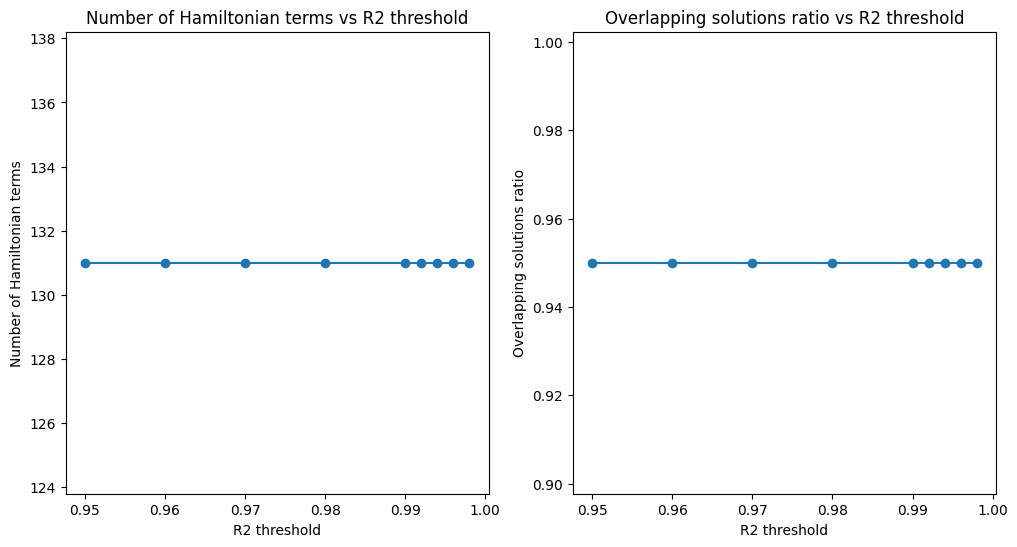

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()

In [24]:
main_seq = "GNLVS" # 4QXX
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold, chunk=50)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/7 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00028896331787109375
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0002510547637939453
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0002048015594482422
h_op size @ k = 4: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.002122163772583008
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.0062847137451171875
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.0074710845947265625
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.007337808609008789
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.007478952407836914
h_op size @ k = 6: 1024
Beads 1 and 4 -- dist_op size: 161
h_op size @ k = 1: 161
Time taken to do composition @ k = 2: 0.001920938491821289
h_op size @ k = 2: 687
Time taken to do composition @ k = 3: 0.0053021907806396484
h_op size @ k = 3: 800
T

 14%|█▍        | 1/7 [00:06<00:36,  6.01s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00017786026000976562
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003039836883544922
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00019693374633789062
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00021195411682128906
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0027189254760742188
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007143974304199219
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008730173110961914
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.008545875549316406
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.008057832717895508
h_op size @ k = 6: 1024
Beads 1 and 4 -- dist_op size: 161
h_op size @ k = 1: 161
Time taken to do composition @ k = 2: 0.002393960952758789
h_op size @ k = 2: 687
T

 29%|██▊       | 2/7 [00:11<00:28,  5.74s/it]

...

 71%|███████▏  | 5/7 [00:28<00:11,  5.84s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00018787384033203125
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00035500526428222656
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0002372264862060547
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0002002716064453125
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00021314620971679688
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0001957416534423828
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0022699832916259766
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007063150405883789
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.00793004035949707
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.008008956909179688
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.008054018020629883
h_

 86%|████████▌ | 6/7 [00:35<00:05,  5.92s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00018978118896484375
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00024890899658203125
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0003120899200439453
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00019669532775878906
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00020599365234375
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.00018715858459472656
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.002248048782348633
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.006979703903198242
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.007498979568481445
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.00746607780456543
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.007803916931152344
h_op

100%|██████████| 7/7 [00:41<00:00,  5.86s/it]


In [25]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.0, 0.4, 0.45, 1.0, 1.0, 0.95, 0.95]


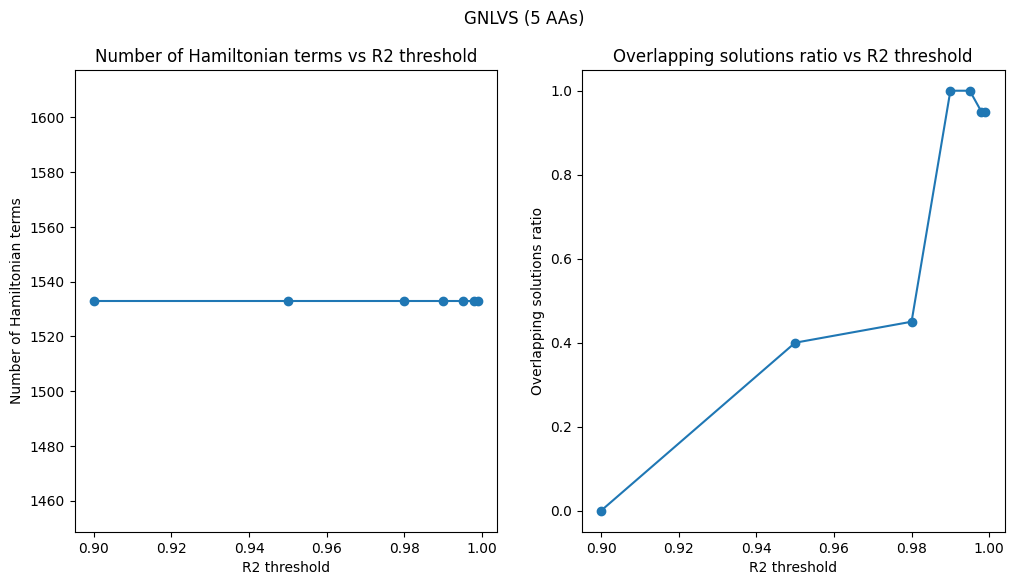

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

fig.suptitle("GNLVS (5 AAs)")

plt.show()


In [9]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold, chunk=40)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    ansatz.measure_all()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)        

  0%|          | 0/7 [00:00<?, ?it/s]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0001800060272216797
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0002338886260986328
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0002148151397705078
h_op size @ k = 4: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0025391578674316406
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007920026779174805
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.00847005844116211
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.008112907409667969
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.009041070938110352
h_op size @ k = 6: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do composition @ k = 2: 0.019073009490966797
h_op size @ k = 2: 8124
Time taken to do composition @ k = 3: 0.16999602317810059
h_op size @ k = 3: 15339
Tim

 14%|█▍        | 1/7 [01:45<10:33, 105.56s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0002880096435546875
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.000202178955078125
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00019097328186035156
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0001850128173828125
h_op size @ k = 5: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0031881332397460938
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007409095764160156
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008491992950439453
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.008421897888183594
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.008084774017333984
h_op size @ k = 6: 1024
Beads 0 and 5 -- dist_op size: 411
h_op size @ k = 1: 411
Time taken to do composition @ k = 2: 0.019813060760498047
h_op size @ k = 2: 8124
Tim

 29%|██▊       | 2/7 [03:33<08:54, 106.83s/it]

...

 71%|███████▏  | 5/7 [08:38<03:23, 101.82s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0001862049102783203
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0002880096435546875
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0002300739288330078
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00021600723266601562
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0002040863037109375
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0002071857452392578
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.002428770065307617
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.008011102676391602
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008695125579833984
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.009042978286743164
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.008689165115356445
h_op

 86%|████████▌ | 6/7 [10:15<01:40, 100.27s/it]

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0002639293670654297
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.00043582916259765625
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.0001971721649169922
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0002560615539550781
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00018930435180664062
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0002620220184326172
h_op size @ k = 7: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0030968189239501953
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007966279983520508
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008558988571166992
h_op size @ k = 4: 1021
Time taken to do composition @ k = 5: 0.008622169494628906
h_op size @ k = 5: 1024
Time taken to do composition @ k = 6: 0.008213043212890625
h_

100%|██████████| 7/7 [12:01<00:00, 103.07s/it]


In [10]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.0, 0.0, 0.0, 0.2, 1.0, 0.9, 0.05]


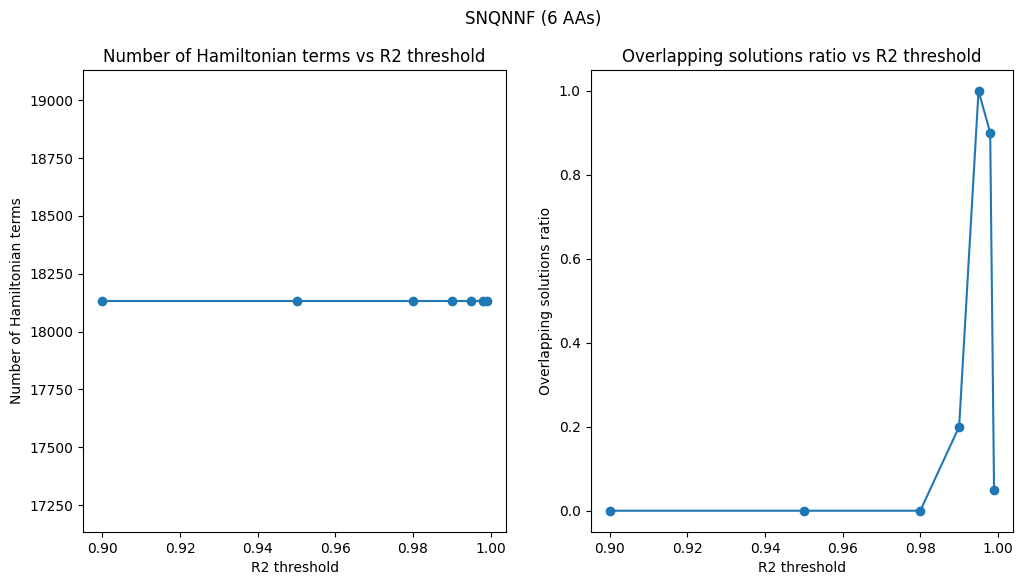

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

fig.suptitle("SNQNNF (6 AAs)")

plt.show()

In [14]:
main_seq = "GSNQNNF"  # 6VHC (linear peptide)
num_aas = len(main_seq)
protein_folding_problem = build_pf(main_seq)

shots = 10_000
# Need MPS simulator: 7AAs -> 33 qubits
sampler = Sampler(
    default_shots=shots, options={"backend_options": {"method": "matrix_product_state"}}
)

num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = [0.999]
for r2_threshold in tqdm(r2_thresholds):
    start_time = time()
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    end_time = time()
    print(
        f"Time taken to build Hamiltonian with R2 threshold {r2_threshold}: {end_time - start_time}"
    )
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(
        optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False
    )
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [
        convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2
    ]
    top_turns_list.append(top_turns_per_r2)

  0%|          | 0/1 [00:00<?, ?it/s]

Time taken to build Hamiltonian with R2 threshold 0.999: 6604.389615774155


100%|██████████| 1/1 [2:27:49<00:00, 8869.63s/it]


In [23]:
opt_results["top_solutions"][:20]

[('110100001111111010111000110100110', -21.365503038157538),
 ('110000111010001110000010000111010', -19.218114392149847),
 ('110100000011111010111000110100110', -18.295503038157538),
 ('110000000010111010111000110111110', -17.67501547347865),
 ('110000001111111010111000110100110', -17.615503038157538),
 ('010100001111111010111000110100110', -17.615503038157538),
 ('110000001110111010111000110111110', -17.585015473478652),
 ('110000001111100010111000110100110', -17.53550303815754),
 ('110100000011111010111100110101010', -16.994462694666083),
 ('110000100010001110000010000101010', -16.645706415660356),
 ('110100000010001010111000110100110', -16.47550303815754),
 ('010010110110011011000010101111010', -16.413920684907943),
 ('110110001111111010111000110100110', -16.32550303815754),
 ('010110100001111010100000110111010', -16.25090722722039),
 ('110000001011111010111000110100110', -16.12550303815754),
 ('110000000111111010111000110100110', -16.03550303815754),
 ('1100010011111110101110001101

In [25]:
top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
print(top_bitstrings_per_r2)
[convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]

['110100001111111010111000110100110', '110000111010001110000010000111010', '110100000011111010111000110100110', '110000000010111010111000110111110', '110000001111111010111000110100110', '010100001111111010111000110100110', '110000001110111010111000110111110', '110000001111100010111000110100110', '110100000011111010111100110101010', '110000100010001110000010000101010', '110100000010001010111000110100110', '010010110110011011000010101111010', '110110001111111010111000110100110', '010110100001111010100000110111010', '110000001011111010111000110100110', '110000000111111010111000110100110', '110001001111111010111000110100110', '110000000010011010111000110111110', '110000000011111010111000110111110', '110000001110111010111000110100110']


['617490',
 '180b90',
 '617490',
 '617390',
 '617490',
 '617490',
 '617390',
 '617490',
 '6b7590',
 '180590',
 '617490',
 '786b90',
 '617490',
 '607b90',
 '617490',
 '617490',
 '617490',
 '617390',
 '617390',
 '617490']

In [15]:
num_hamiltonian_terms

[266454]

In [18]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{num_aas}AA_{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.05]


In [21]:
print(top_turns_list[0])
print(top_cls_turns)

['617490', '180b90', '617490', '617390', '617490', '617490', '617390', '617490', '6b7590', '180590', '617490', '786b90', '617490', '607b90', '617490', '617490', '617490', '617390', '617390', '617490']
['687590', '4a7590', '0b3590', '075b20', '071a90', '057920', 'a79b80', 'b58a90', '143a90', '361b80', '392780', '180590', '0b1580', '281580', '497580', '978a90', '03b590', '275a20', '257820', '071490']


## QubitOpBuilder test

In [8]:
# main_seq = "LFLF" # 6MVZ
# main_seq = "GNLVS" # 4QXX
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

Highest degree of the polynomial for 0 and 3: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 414
Highest degree of the polynomial for 0 and 4: 10
Polynomial coefficients: [ 4.99832488e+01 -6.02757162e+01  2.79964489e+01 -6.80593446e+00
  9.81171530e-01 -8.91697182e-02  5.24256098e-03 -1.98943849e-04
  4.70209240e-06 -6.29233776e-08  3.64019540e-10]
Number of h_olap terms: 9579
Highest degree of the polynomial for 0 and 5: 12
Polynomial coefficients: [ 4.99519820e+01 -5.71877241e+01  2.49724697e+01 -5.71448277e+00
  7.84640519e-01 -6.95221168e-02  4.14026698e-03 -1.69025082e-04
  4.74015109e-06 -8.97477398e-08  1.09585694e-09 -7.78864271e-12
  2.44741161e-14]
Number of h_olap terms: 180823
Highest degree of the polynomial for 1 and 4: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e

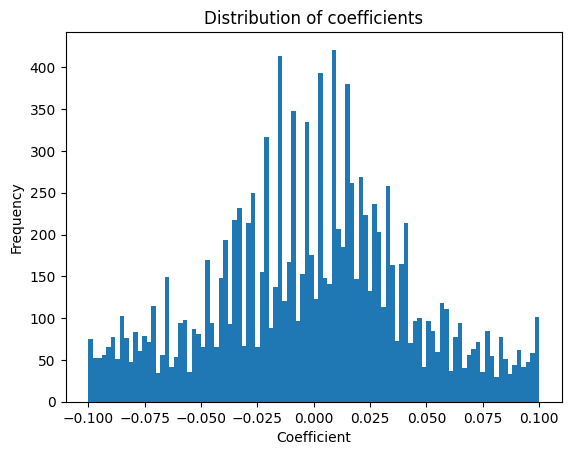

In [24]:
# Plot the distribution of the coefficients
coefficients = np.real(qubit_op.coeffs[1:])
plt.hist(coefficients, bins=100, range=(-0.1, 0.1))
plt.xlabel("Coefficient")
plt.ylabel("Frequency")
plt.title("Distribution of coefficients")
plt.show()

In [16]:
# truncated_qubit_op = qubit_op.chop(0.001)
# print(f"Number of final h_olap terms (truncated): {len(truncated_qubit_op)}")

shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 500
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.42 seconds
 >> Processing 8923 unique bitstrings took 0.56 seconds
 >> Sampler job took 0.41 seconds
 >> Processing 7452 unique bitstrings took 0.41 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6559 unique bitstrings took 0.32 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6553 unique bitstrings took 0.33 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6851 unique bitstrings took 0.35 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6661 unique bitstrings took 0.34 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 7213 unique bitstrings took 0.36 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6182 unique bitstrings took 0.31 seconds
 >> Sampler job took 0.39 seconds
 >> Processing 6158 unique bitstrings took 0.30 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 6101 unique bitstrings took 0.42 seconds
 >> Sampler job took 0.40 seconds
 >> Processing 5704 unique bitstrings took 0.30 seconds
 >> Sample

In [17]:
opt_results["top_solutions"]

[('011101111000011110101011', -17.965442978456487),
 ('011101111011010010011011', -17.96544297821768),
 ('011101111100011110101011', -16.47544297845649),
 ('011101111111010010011011', -16.47544297821768),
 ('011101101000011110101011', -16.38544297845649),
 ('011101110000011110101011', -16.38544297845649),
 ('011101110011010010011011', -16.385442978217682),
 ('011101101011010010011011', -16.385442978217682),
 ('011111111000011110101011', -16.285442978456487),
 ('011100111000011110101011', -16.285442978456487),
 ('011111111011010010011011', -16.28544297821768),
 ('011100111011010010011011', -16.28544297821768),
 ('010101111000011110101011', -16.255442978456486),
 ('010101111011010010011011', -16.25544297821768),
 ('011101110100011110101011', -14.89544297845649),
 ('011101110111010010011011', -14.89544297821768),
 ('011101101111010010011011', -14.895442978217678),
 ('111110110100011010111011', -14.841181357723768),
 ('011101100000011110101011', -14.80544297845649),
 ('01110110001101001001

In [18]:
for i in range(10):
    best_solution = opt_results["top_solutions"][i][0]
    print(convert_bitstring_to_turns(best_solution, main_seq))

8b520
a9720
8b520
a9720
8b520
8b520
a9720
a9720
8b520
8b520


In [31]:
# Get the top 10 solutions from classical search
main_seq = "SNQNNF" # 2OL9
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:10]
top_cls_turns

['85b20',
 'a7920',
 '36120',
 '34120',
 '41580',
 '39b80',
 '70590',
 '81a90',
 '18a90',
 '07120']

In [19]:
# main_seq = "LFLF" # 6MVZ
main_seq = "GNLVS" # 4QXX
# main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

Highest degree of the polynomial for 0 and 3: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 414
Highest degree of the polynomial for 0 and 4: 10
Polynomial coefficients: [ 4.99832488e+01 -6.02757162e+01  2.79964489e+01 -6.80593446e+00
  9.81171530e-01 -8.91697182e-02  5.24256098e-03 -1.98943849e-04
  4.70209240e-06 -6.29233776e-08  3.64019540e-10]
Number of h_olap terms: 9579
Highest degree of the polynomial for 1 and 4: 7
Polynomial coefficients: [ 4.99814891e+01 -5.78089631e+01  2.49544340e+01 -5.37100537e+00
  6.35840875e-01 -4.20496324e-02  1.45526961e-03 -2.05160189e-05]
Number of h_olap terms: 14450
Number of final h_olap terms: 1533


In [20]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 200
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.02 seconds
 >> Processing 4087 unique bitstrings took 0.04 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 2124 unique bitstrings took 0.02 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 1131 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 712 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 710 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 473 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 825 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 721 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 556 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 528 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 404 unique bitstrings took 0.01 seconds
 >> Sampler job to

In [23]:
opt_results["top_solutions"]

[('1010110010111110', -13.962514410708469),
 ('1001111001110010', -13.408358352862171),
 ('1011011100100110', -13.376663577043587),
 ('1100110000111010', -13.156776031448427),
 ('1001111010111010', -12.445791507984957),
 ('1011110010111110', -12.142514410708468),
 ('1011101110101011', -12.078358352909847),
 ('1011100010011011', -12.078358352868467),
 ('1101111001110010', -11.82835835286217),
 ('1101010001101010', -11.608358352892282),
 ('1000111001110010', -11.588358352862171),
 ('1000110000111010', -11.576776031448425),
 ('0011111100111110', -11.355791507947432),
 ('1000110101110010', -11.177878328740551),
 ('1000110010111110', -11.13251441070847),
 ('1000111101110010', -11.132514410695652),
 ('0111110110111110', -10.7383583528919),
 ('1000111010111010', -10.625791507984959),
 ('1001011100100110', -10.546663577043585),
 ('1111101110101011', -10.498358352909845),
 ('1111100010011011', -10.498358352868468),
 ('1101101101110011', -10.310053128716508),
 ('1101100001110011', -10.3100531287

In [24]:
for i in range(10):
    best_solution = opt_results["top_solutions"][i][0]
    print(convert_bitstring_to_turns(best_solution, main_seq))

9390
4190
1490
0b90
5b90
9390
b520
9720
4190
8590


In [30]:
# Get the top 10 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:10]
top_cls_turns

['6390',
 '9390',
 '4190',
 '5b90',
 '0b90',
 '1490',
 'b090',
 'a490',
 '1390',
 '7390']

We can try truncating the qubit operator to keep only the terms with the relatively large coefficients. How does this affect the quality of the solutions?

In [33]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.999)
print(f"Number of final h_olap terms: {len(qubit_op)}")

/Users/lir9/protein-folding-qc/notebooks/../fcc/fcc_qubit_op_builder.py:261: SyntaxWarning: invalid escape sequence '\l'
  """


Number of final h_olap terms: 18133


In [35]:
truncation_thresholds = [0.1, 0.01, 0.001, 0.0001]
num_hamiltonian_terms = []
top_turns_list = []

for truncation_threshold in tqdm(truncation_thresholds):
    truncated_qubit_op = qubit_op.chop(truncation_threshold)
    num_hamiltonian_terms.append(len(truncated_qubit_op))

    ansatz = RealAmplitudes(truncated_qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=truncated_qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_trunc = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_trunc = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_trunc]
    top_turns_list.append(top_turns_per_trunc)

100%|██████████| 4/4 [06:32<00:00, 98.02s/it]


In [36]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_trunc in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_trunc if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

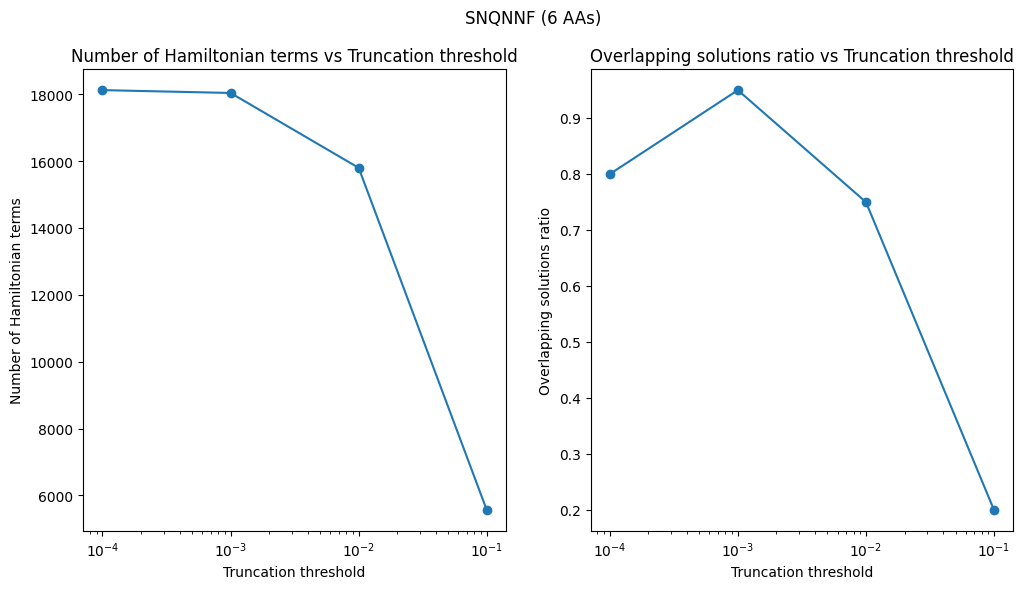

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(truncation_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xscale("log")
axs[0].set_xlabel("Truncation threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs Truncation threshold")

axs[1].plot(truncation_thresholds, overlapping_solutions_ratio, marker='o')
axs[1].set_xscale("log")
axs[1].set_xlabel("Truncation threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs Truncation threshold")

fig.suptitle("SNQNNF (6 AAs)")

plt.show()